# Introduction

This notebook provides a guide on how to perform MLIP property calculations with MatCalc.

For the purposes of this notebook, we will only use the TensorNet PBE and r2SCAN and MACE-MPA-0 foundation potentials. These requires MatGL and mace-torch to be installed. Uncomment the next cell to install these packages if you do not already have them.

In [ ]:
#! uv pip install matcalc "matgl>=2.2.0" mace-torch

Using Python 3.11.15 environment at: /Users/shyue/repos/matcalc/.venv
Checked 3 packages in 68ms


In [ ]:
from __future__ import annotations

import warnings
from time import perf_counter
import pandas as pd

import matplotlib.pyplot as plt
from pymatgen.ext.matproj import MPRester
from tqdm import tqdm
import plotly.express as px

from matcalc import ElasticityCalc, EOSCalc, RelaxCalc, ChainedCalc

warnings.filterwarnings("ignore", category=UserWarning)

# Obtaining Test Structures from the Materials Project

We will first use Pymatgen's MPRester to obtain a few LiCl, NaCl, Li2O and Na2O structures from the Materials Project for demonstration purposes. We will only keep structures with < 20 atoms to speed up the calculations.

In [ ]:
mp_data = MPRester().materials.summary.search(
    formula=["LiCl", "Li2O", "NaCl", "Na2O"], _fields=["material_id", "structure", "energy_above_hull"]
)
mp_data.sort(key=lambda d: d["energy_above_hull"])
mp_data = [d for d in mp_data if len(d["structure"]) < 20]

print(f"{len(mp_data)} structures were downloaded")

14 structures were downloaded


# Setup

Let us set some parameters we will be using.

In [ ]:
# This is the list of models we are using for this demo.
models = ["TensorNet-PES-MatPES-PBE-2025.2", "TensorNet-PES-MatPES-r2SCAN-2025.2", "MACE"]

# This is the max force used for EOS and Elasticity calculations.
fmax = 0.01
optimizer = "BFGSLineSearch"
units_GPa = True

# Example 1: Running ElasticityCalc on one structure

In [ ]:
prop_calc = ElasticityCalc("TensorNet-PES-MatPES-PBE-2025.2", relax_structure=True, fmax=fmax, units_GPa=units_GPa)
prop_calc.calc(mp_data[0])

model.json: 0.00B [00:00, ?B/s]

{'material_id': 'mp-1960',
 'structure': Structure Summary
 Lattice
     abc : 3.247559353206847 3.2475593638616553 3.2475592482660733
  angles : 59.999997984648196 59.99999736839454 59.999999300874734
  volume : 24.21900312769648
       A : np.float64(2.812468735584862) np.float64(8.235574002114832e-08) np.float64(1.623779961681679)
       B : np.float64(0.937489334402092) np.float64(2.651621060068274) np.float64(1.623779949220412)
       C : np.float64(-1.8001902765805398e-07) np.float64(-1.4255457209486227e-07) np.float64(3.2475592482660653)
     pbc : True True True
 PeriodicSite: Li (2.812, 1.989, 4.871) [0.75, 0.75, 0.75]
 PeriodicSite: Li (0.9375, 0.6629, 1.624) [0.25, 0.25, 0.25]
 PeriodicSite: O (-1.776e-09, -3.32e-08, 4.192e-08) [3.542e-09, -1.252e-08, 1.74e-08],
 'energy_above_hull': 0.0,
 'final_structure': Structure Summary
 Lattice
     abc : 3.247559353206847 3.2475593638616553 3.2475592482660733
  angles : 59.999997984648196 59.99999736839454 59.999999300874734
  volume

A few notes about the args adn return values from a PropCalc.
1. The input can be a structure or a dict containing a structure key.
2. The return value is always a dictionary that contains all the original keys from the input.


## Example 2: Chaining Calculators

Very often, you want to run multiple calculations using the same MLIP. This can be done using ChainedCalc. One thing to note that you typically do not want to waste compute re-relaxing the structure after the first relaxation. So the `relax_structure` parameter for other calculators are set to False.

In [ ]:
propcalc = ChainedCalc([
    RelaxCalc("TensorNet-PES-MatPES-PBE-2025.2", fmax=fmax, optimizer=optimizer), 
    ElasticityCalc("TensorNet-PES-MatPES-PBE-2025.2", fmax=fmax, relax_structure=False), 
    EOSCalc("TensorNet-PES-MatPES-PBE-2025.2", fmax=fmax, optimizer=optimizer, relax_structure=False)])
propcalc.calc(mp_data[0])

{'material_id': 'mp-1960',
 'structure': Structure Summary
 Lattice
     abc : 3.249439001162373 3.2494388590153105 3.249438704558706
  angles : 59.99999730235668 59.999997059146914 59.99999933714865
  volume : 24.261077721141973
       A : np.float64(2.8140965816400363) np.float64(5.0979613595178364e-08) np.float64(1.624719745518279)
       B : np.float64(0.9380319367526798) np.float64(2.653155643288971) np.float64(1.6247197040088563)
       C : np.float64(-1.1604317959357046e-07) np.float64(-1.3289338688156626e-07) np.float64(3.249438704558701)
     pbc : True True True
 PeriodicSite: Li (2.814, 1.99, 4.874) [0.75, 0.75, 0.75]
 PeriodicSite: Li (0.938, 0.6633, 1.625) [0.25, 0.25, 0.25]
 PeriodicSite: O (-7.614e-09, 1.442e-09, 6.938e-08) [-2.887e-09, 5.434e-10, 2.252e-08],
 'energy_above_hull': 0.0,
 'final_structure': Structure Summary
 Lattice
     abc : 3.249439001162373 3.2494388590153105 3.249438704558706
  angles : 59.99999730235668 59.999997059146914 59.99999933714865
  volume 

Note that the final result dict contains keys from all calculators, including `final_structure` from `RelaxCalc`, `bulk_modulus_vrh` and `shear_modulus_vrh` from ElasticityCalc, and `eos` and `bulk_modulus_bm` from EOSCalc.

## Example 3: Multiple Properties with Multiple MLIPs

In this final example, we will bring everything together with multiple properties with multiple MLIPs. We will use ChainedCalc from Example 2 to make things easier.

In [ ]:
prop_preds = []

for dct in (pbar := tqdm(mp_data)):
    mat_id, structure = dct["material_id"], dct["structure"]
    formula = structure.reduced_formula
    pbar.set_description(f"Running {mat_id} ({formula})")

    for model in models:
        propcalc = ChainedCalc([
            RelaxCalc(model, fmax=fmax, optimizer=optimizer), 
            ElasticityCalc(model, fmax=fmax, relax_structure=False, units_GPa=True), 
            EOSCalc(model, fmax=fmax, optimizer=optimizer, relax_structure=False)])
        results = propcalc.calc(dct)
        prop_preds.append({
            "material_id": mat_id, 
            "formula": formula,
            "model": model,
        } | {k: results[k] for k in ["final_structure", "bulk_modulus_vrh", "shear_modulus_vrh", "bulk_modulus_bm", "eos"]}
                         )


Running mp-1960 (Li2O):   0%|                                                                                                | 0/14 [00:00<?, ?it/s]

model.pt:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

state.pt:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

model.json: 0.00B [00:00, ?B/s]

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


...

Running mp-1975297 (Na2O):  86%|████████████████████████████████████████████████████████████████████████            | 12/14 [02:33<00:38, 19.40s/it]WARNING:root:Default dtype float32 does not match model dtype float64, converting models to float32.


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which

Running mp-22851 (NaCl):  93%|███████████████████████████████████████████████████████████████████████████████▊      | 13/14 [02:48<00:17, 17.97s/it]WARNING:root:Default dtype float32 does not match model dtype float64, converting models to float32.


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/shyue/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which

Running mp-22851 (NaCl): 100%|██████████████████████████████████████████████████████████████████████████████████████| 14/14 [02:53<00:00, 12.38s/it]


To make it easier to work with, we will convert our results into a pandas DataFrame.

In [ ]:
df_preds = pd.DataFrame(prop_preds)
df_preds["label"] = df_preds["material_id"] + "-" + df_preds["formula"]
df_preds.head()


,material_id,formula,model,final_structure,bulk_modulus_vrh,shear_modulus_vrh,bulk_modulus_bm,eos,label
0,mp-1960,Li2O,TensorNet-PES-MatPES-PBE-2025.2,"[[2.8140967 1.98986703 4.8741591 ] Li, [0.938...",75.812487,66.798505,77.559612,"{'volumes': [17.68633383637635, 18.89181882356...",mp-1960-Li2O
1,mp-1960,Li2O,TensorNet-PES-MatPES-r2SCAN-2025.2,"[[2.80965035 1.98672293 4.86645778] Li, [0.936...",94.694582,80.065328,93.524052,"{'volumes': [17.6026311420152, 18.802411027041...",mp-1960-Li2O
2,mp-1960,Li2O,MACE,"[[2.8555012 2.01914431 4.94587441] Li, [0.951...",84.160866,58.700427,83.746975,"{'volumes': [18.478552140180852, 19.7380340314...",mp-1960-Li2O
3,mp-2352,Na2O,TensorNet-PES-MatPES-PBE-2025.2,"[[3.4280588 2.42400413 5.93757306] Na, [1.142...",46.646647,29.609316,46.417502,"{'volumes': [31.97169067460796, 34.15085304256...",mp-2352-Na2O
4,mp-2352,Na2O,TensorNet-PES-MatPES-r2SCAN-2025.2,"[[3.34320545 2.36400375 5.79060285] Na, [1.114...",56.539944,37.241689,56.896821,"{'volumes': [29.655826073846054, 31.6771411437...",mp-2352-Na2O


## Plotting

We will now use plotly to make a few plots of the bulk modulus from ElasticityCalc and EOSCalc for comparisons.

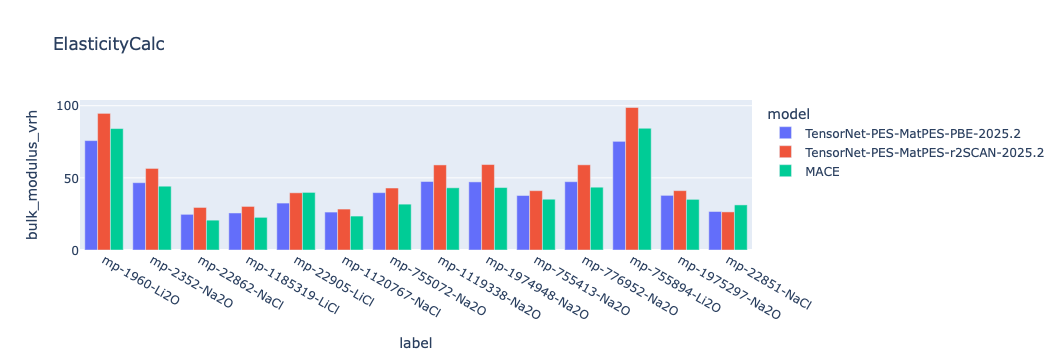

In [ ]:
px.bar(data_frame=df_preds, x="label", y="bulk_modulus_vrh", color="model", barmode="group", title="ElasticityCalc")

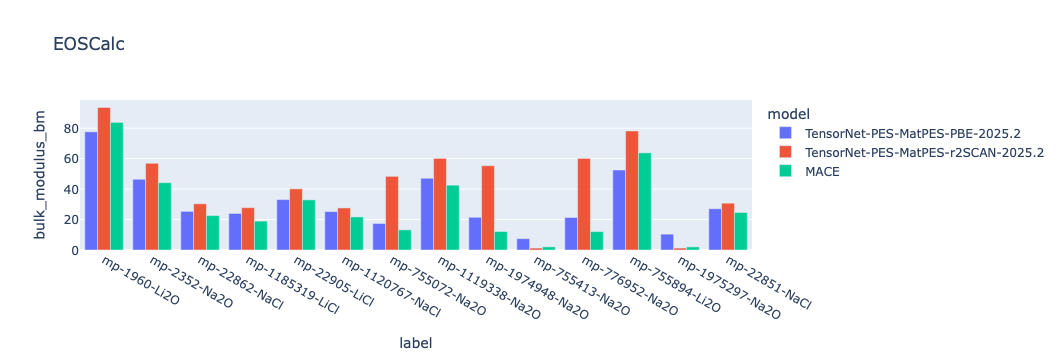

In [ ]:
px.bar(data_frame=df_preds, x="label", y="bulk_modulus_bm", color="model", barmode="group", title="EOSCalc")

This is strange, but the EOSCalc results seem to make more sense. TensorNet-MatPES-PBE and MACE-MPA-0 are expected to yield similar results since they are based on the same PBE functional. The TensorNet-MatPES-r2SCAN foundation potential is expected to yield different results. The ElasticityCalc results show large differences between TensorNet-MatPES-PBE and MACE-MPA-0, but the EOSCalc shows much smaller differences. Let us compare the differences within the same model.

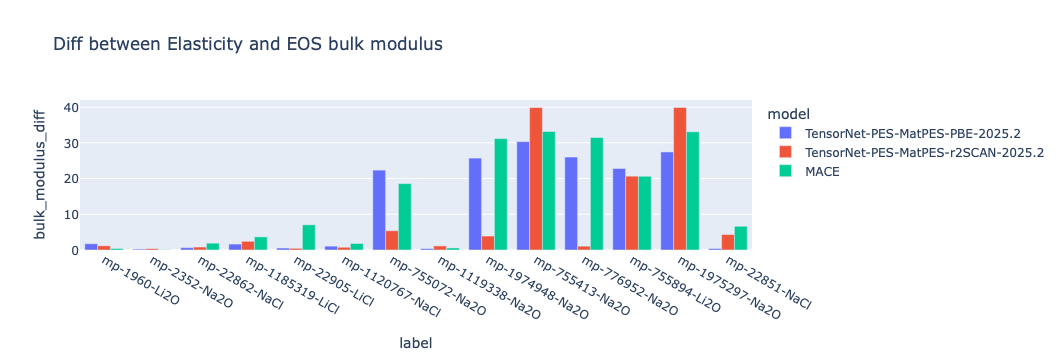

In [ ]:
df_preds["bulk_modulus_diff"] = (df_preds["bulk_modulus_vrh"] - df_preds["bulk_modulus_bm"]).abs()
px.bar(data_frame=df_preds, x="label", y="bulk_modulus_diff", color="model", barmode="group", title="Diff between Elasticity and EOS bulk modulus")

Quite clearly the MACE-MPA-0 shows much bigger inconsistencies for this limited subset of materials tested. This is not totally unexpected since the training dataset of MACE-MPA-0 is based on old MPRelax settings with poorer convergence settings. The MatPES dataset is a much more modern dataset with better convergence settings.

## EOS Curves

We will plot just one EOS curve as an illustration.

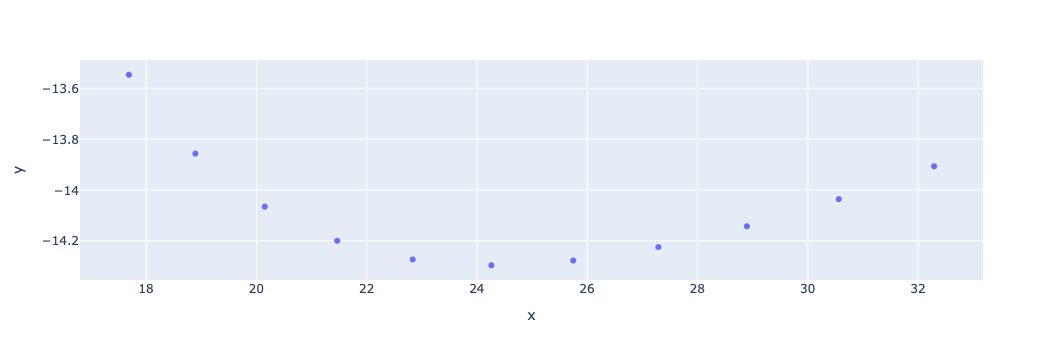

In [ ]:
eos = df_preds["eos"][0]

px.scatter(x=eos["volumes"], y=eos["energies"])